# CIENCIA DE LA COMPUTACION
### Facultad de Ciencias 
---
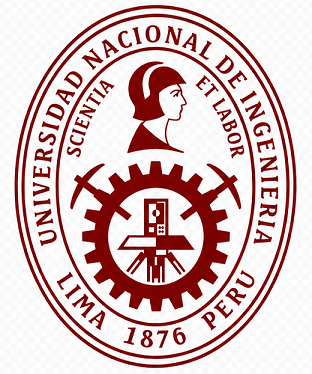
---

### Curso: Inteligencia Artificial (CC421A)
### Profesor: Dr. Marco Antonio Alania Vicente
---
# TEMA: DETECCION DE OBJETOS - MODELO YOLO 11
---
---

## TIPO DE MODELO EN YOLO

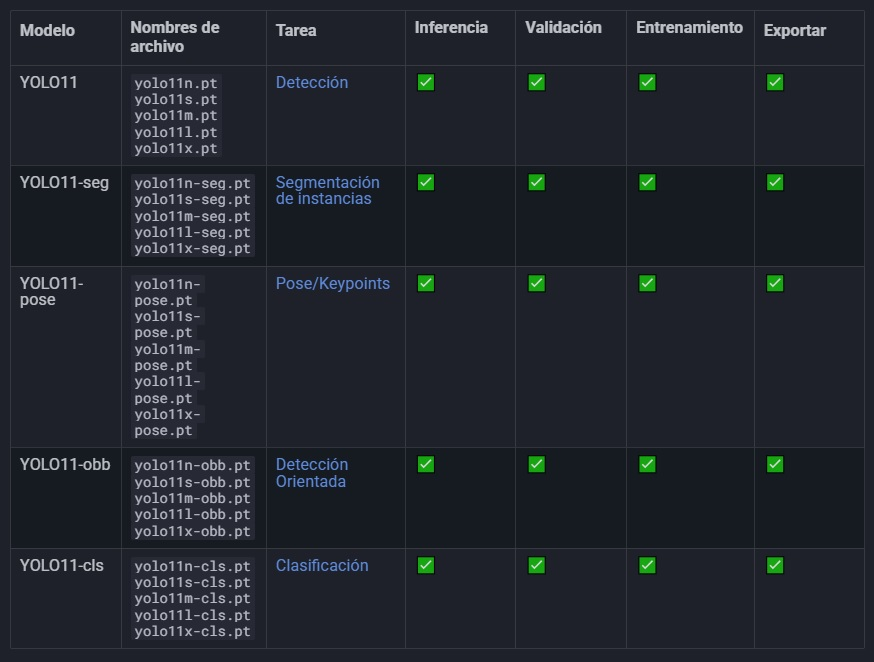

Con YOLO 11 permite realizar tareas como:

- Deteccion
- Clasificacion
- Segmentacion de instancias
- Seguimiento multiobjeto
- Poses
- Cajas delimitadoras orientadas (OBB)

<br><img width="1024" src="https://raw.githubusercontent.com/ultralytics/assets/main/im/banner-tasks.png">

# Deteccion de Objetos [1]
Detecta objetos en una imagen en particular fija. Se usa los parametros del propio modelo para identificar

In [15]:
from ultralytics import YOLO
import os

# Obtener el directorio actual del script
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# path de la imagen donde se aplicara la deteccion, solo una imagen a la vez
print("[INFO] Ruta: ",script_dir)
source = os.path.join(script_dir, "Imagen_Deteccion", "persona_01.jpg")

# realizamos la prediccion con YOLO de la imagen
result=model(source)
print(result) # se visualiza x terminal

# visualizamos el resultado, solo una imagen
result[0].show()
print("[INFO] FIN DEL PROGRAMA ..........")


[INFO] Ruta:  d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\DETECCION_YOLO

image 1/1 d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\DETECCION_YOLO\Imagen_Deteccion\persona_01.jpg: 512x640 3 persons, 2 traffic lights, 172.9ms
Speed: 16.4ms preprocess, 172.9ms inference, 5.1ms postprocess per image at shape (1, 3, 512, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard',

# Deteccion de Objetos [2]
Detecta objetos en cuatro imagenes en particular fija. Se usa los parametros del propio modelo para identificar

In [2]:
from ultralytics import YOLO
import os

# Obtener el directorio actual del script
#script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# Lista de nombres de imágenes
image_names = ["persona_01.jpg", "persona_02.jpg", "persona_03.jpg", "persona_04.jpg"]

# Por esta (porque Imagen_Deteccion está dentro de MODELO_YOLO):
image_folder = os.path.join(script_dir, "Imagen_Deteccion")
image_paths = [os.path.join(image_folder, name) for name in image_names]

# Normalizar rutas (opcional pero útil)
image_paths = [os.path.normpath(path) for path in image_paths]

# Mostrar rutas para verificar
for path in image_paths:
    print("[INFO] Imagen a procesar:", path)

# Realizar la detección
print("\n[INFO] Resultado de procesamiento")
results = model(image_paths)

# visualizamos el resultado, todas las imagenes
for result in results:
    print("========================================================================================================")
    print(result.boxes)
    result.show()

print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] Imagen a procesar: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\DETECCION_YOLO\Imagen_Deteccion\persona_01.jpg
[INFO] Imagen a procesar: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\DETECCION_YOLO\Imagen_Deteccion\persona_02.jpg
[INFO] Imagen a procesar: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\DETECCION_YOLO\Imagen_Deteccion\persona_03.jpg
[INFO] Imagen a procesar: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\DETECCION_YOLO\Imagen_Deteccion\persona_04.jpg

[INFO] Resultado de procesamiento

0: 640x640 3 persons, 2 traffic lights, 127.8ms
1: 640x640 5 persons, 6 cars, 127.8ms
2: 640x640 1 person, 2 cats, 127.8ms
3: 640x640 3 persons, 4 bicycles, 127.8ms
Speed: 6.2ms preprocess, 127.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 9., 9.])
conf: tensor([0.9081, 0.9053, 0.8080, 0.7250, 0.5710])
data: tensor([[4.9655e+02, 1.4115e+02, 6.8741e+02, 4.6620e+02, 9.0808e-01, 0.0000e+00],
      

# Deteccion de Objetos [3]
Detecta objetos en una imagene en particular fija, usando OpenCV y se manipula las coordenadas de la caja delimitadora. Se usa los parametros del propio modelo para identificar

In [3]:
from ultralytics import YOLO
import os
import cv2

# Obtener el directorio actual del script
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# Cargamos la imagen de entrada de donde lee openCV
image_path = os.path.join(script_dir, "Imagen_Deteccion", "persona_01.jpg")
image = cv2.imread(image_path)

# Realizamos la inferencia sobre la imagen
results = model(image)

for result in results:
    # Extraemos los nombres de las clases detectadas
    names = [result.names[int(label)] for label in result.boxes.cls]
    # Extraemos las coordenadas de las cajas delimitadoras
    print("\n[INFO] IMPRESION DE CAJAS DELIMITADORA\n")
    xyxys = result.boxes.xyxy
    for i, xyxy in enumerate(xyxys):
        print(f"[INFO] Caja Obj[{i}]: {names[i]}")
        x1, y1 = int(xyxy[0]), int(xyxy[1])
        print("[INFO] Punto Superior: (", x1,",",y1,")")
        x2, y2 = int(xyxy[2]), int(xyxy[3])
        print("[INFO] Punto Inferior: (", x2,",",y2,")\n")
        # Dibujar la caja
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)
        # Poner la etiqueta
        texto = f"Obj[{i}]: {names[i]}"
        cv2.putText(image, texto, (x1, y1 - 5), 1, 1.1, (0, 0, 255), 2)
        
    # Mostrar la imagen con las detecciones
    cv2.imshow("Deteccion de Objetos [3] - Presiona 'q' para Salir", image)
    cv2.waitKey(0)
cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")


0: 512x640 3 persons, 2 traffic lights, 116.5ms
Speed: 4.5ms preprocess, 116.5ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)

[INFO] IMPRESION DE CAJAS DELIMITADORA

[INFO] Caja Obj[0]: person
[INFO] Punto Superior: ( 496 , 141 )
[INFO] Punto Inferior: ( 687 , 466 )

[INFO] Caja Obj[1]: person
[INFO] Punto Superior: ( 280 , 124 )
[INFO] Punto Inferior: ( 456 , 530 )

[INFO] Caja Obj[2]: person
[INFO] Punto Superior: ( 122 , 86 )
[INFO] Punto Inferior: ( 251 , 518 )

[INFO] Caja Obj[3]: traffic light
[INFO] Punto Superior: ( 320 , 14 )
[INFO] Punto Inferior: ( 378 , 100 )

[INFO] Caja Obj[4]: traffic light
[INFO] Punto Superior: ( 285 , 36 )
[INFO] Punto Inferior: ( 317 , 120 )

[INFO] FIN DEL PROGRAMA ..........


# Deteccion de Objetos [4]
Detecta objetos de un video en particular fijo, usando OpenCV. Se usa los parametros del propio modelo para identificar

In [16]:
from ultralytics import YOLO
import os
import cv2

# Obtener el directorio actual del script
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# path de la imagen donde se aplicara la deteccion
print("Ruta: ",script_dir)
#video_path="./MODELO_YOLO/Imagen_Deteccion/video.mp4"
video_path=os.path.join(script_dir, "Imagen_Deteccion", "video_2.mp4") 

#cargamos el video de la ruta asignada
cap=cv2.VideoCapture(video_path)

while cap.isOpened():
    # leemos el frame del video
    ret, frame=cap.read()
    if not ret:
        break

    # realizamos la inferencia de YOLO sobre el frame
    results=model(frame)

    # extraemos los resultados
    annotated_frame=results[0].plot()

    # visualizamos los resultados
    cv2.imshow("Deteccion de Objetos [4] - Presiona 'q' para Salir",annotated_frame)

    # el ciclo se rompe al presionar ESC
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")

Ruta:  d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\DETECCION_YOLO

0: 384x640 10 cars, 1 truck, 140.2ms
Speed: 5.6ms preprocess, 140.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 1 truck, 358.7ms
Speed: 7.6ms preprocess, 358.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 1 truck, 148.7ms
Speed: 21.6ms preprocess, 148.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 121.4ms
Speed: 5.5ms preprocess, 121.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 149.7ms
Speed: 5.9ms preprocess, 149.7ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 149.6ms
Speed: 8.3ms preprocess, 149.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 147.1ms
Speed: 3.9ms preprocess, 147.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 130.

# Deteccion de Objetos [5]
Detecta objetos de la camara de la computadora usando el OpenCV. Se usa los parametros del propio modelo para identificar

In [11]:
from ultralytics import YOLO
import os
import cv2

# Obtener el directorio actual del script
# script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

#cargamos el video del webcam
cap=cv2.VideoCapture(0)

while cap.isOpened():
    # leemos el frame del video
    ret, frame=cap.read()
    if not ret:
        break

    # realizamos la inferencia de YOLO sobre el frame
    results=model(frame)

    # extraemos los resultados
    annotated_frame=results[0].plot()

    # visualizamos los resultados
    cv2.imshow("Deteccion de Objetos [5] - Presiona 'q' para Salir",annotated_frame)

    # el ciclo se rompe al presionar ESC
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] FIN DEL PROGRAMA ..........


# Deteccion de Objetos [6]
Detecta multiple objetos, con diferentes camaras, las cuales estan conectadas e instaladas en la computadora donde se ejecute el script, se usa para esto el OpenCV. Se usa los parametros del propio modelo para identificar

In [14]:
from ultralytics import YOLO
import os
import cv2
import threading
import time

# ===============================
# CARGA DEL MODELO
# ===============================
script_dir = os.getcwd()
model_path = os.path.join(script_dir, "yolo11n.pt")

# ===============================
# DETECTAR CÁMARAS DISPONIBLES
# ===============================
def detectar_camaras(max_test=10):
    camaras_disponibles = []

    for i in range(max_test):
        cap = cv2.VideoCapture(i, cv2.CAP_DSHOW)  # CAP_DSHOW recomendado en Windows

        if cap is not None and cap.isOpened():
            ret, frame = cap.read()
            if ret:
                camaras_disponibles.append(i)

            cap.release()

    return camaras_disponibles


# ===============================
# HILO PARA CADA CÁMARA
# ===============================
class CamaraYOLO(threading.Thread):
    def __init__(self, cam_id, model_path, stop_event):
        super().__init__()
        self.cam_id = cam_id
        self.model_path = model_path
        self.stop_event = stop_event
        self.frame_actual = None
        self.lock = threading.Lock()

    def run(self):
        print(f"[INFO] Iniciando camara {self.cam_id}")

        # Cada cámara carga su propio modelo YOLO
        model = YOLO(self.model_path)

        cap = cv2.VideoCapture(self.cam_id, cv2.CAP_DSHOW)

        if not cap.isOpened():
            print(f"[ERROR] No se pudo abrir la camara {self.cam_id}")
            return

        # Resolución base de la cámara
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

        while not self.stop_event.is_set():
            ret, frame = cap.read()

            if not ret:
                print(f"[ERROR] No se pudo leer frame de la camara {self.cam_id}")
                time.sleep(0.05)
                continue

            # Inferencia YOLO
            results = model.predict(
                frame,
                imgsz=640,
                conf=0.25,
                verbose=False
            )

            annotated = results[0].plot()

            # Guardar último frame procesado
            with self.lock:
                self.frame_actual = annotated.copy()

        cap.release()
        print(f"[INFO] Camara {self.cam_id} liberada")

    def obtener_frame(self):
        with self.lock:
            if self.frame_actual is None:
                return None
            return self.frame_actual.copy()


# ===============================
# PROGRAMA PRINCIPAL
# ===============================
ids_camaras = detectar_camaras(max_test=10)

print(f"[INFO] Camaras encontradas: {ids_camaras}")

if len(ids_camaras) == 0:
    print("[ERROR] No se encontro ninguna camara.")
    exit()

stop_event = threading.Event()

# Crear un hilo por cámara
hilos_camaras = []

for cam_id in ids_camaras:
    hilo = CamaraYOLO(cam_id, model_path, stop_event)
    hilo.start()
    hilos_camaras.append(hilo)

print("[INFO] Todas las camaras estan trabajando simultaneamente.")
print("[INFO] Presiona 'q' para salir.")

# Mostrar las ventanas desde el hilo principal
while True:
    for hilo in hilos_camaras:
        frame = hilo.obtener_frame()

        if frame is not None:
            cv2.imshow(
                f"Camara {hilo.cam_id} - YOLO - presiona 'q' para salir",
                frame
            )

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Detener todos los hilos
stop_event.set()

for hilo in hilos_camaras:
    hilo.join()

cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] Camaras encontradas: [0, 1]
[INFO] Iniciando camara 0
[INFO] Iniciando camara 1
[INFO] Todas las camaras estan trabajando simultaneamente.
[INFO] Presiona 'q' para salir.
[INFO] Camara 1 liberada
[INFO] Camara 0 liberada
[INFO] FIN DEL PROGRAMA ..........
